(0.19973708736411086, 1.8056924151855671)

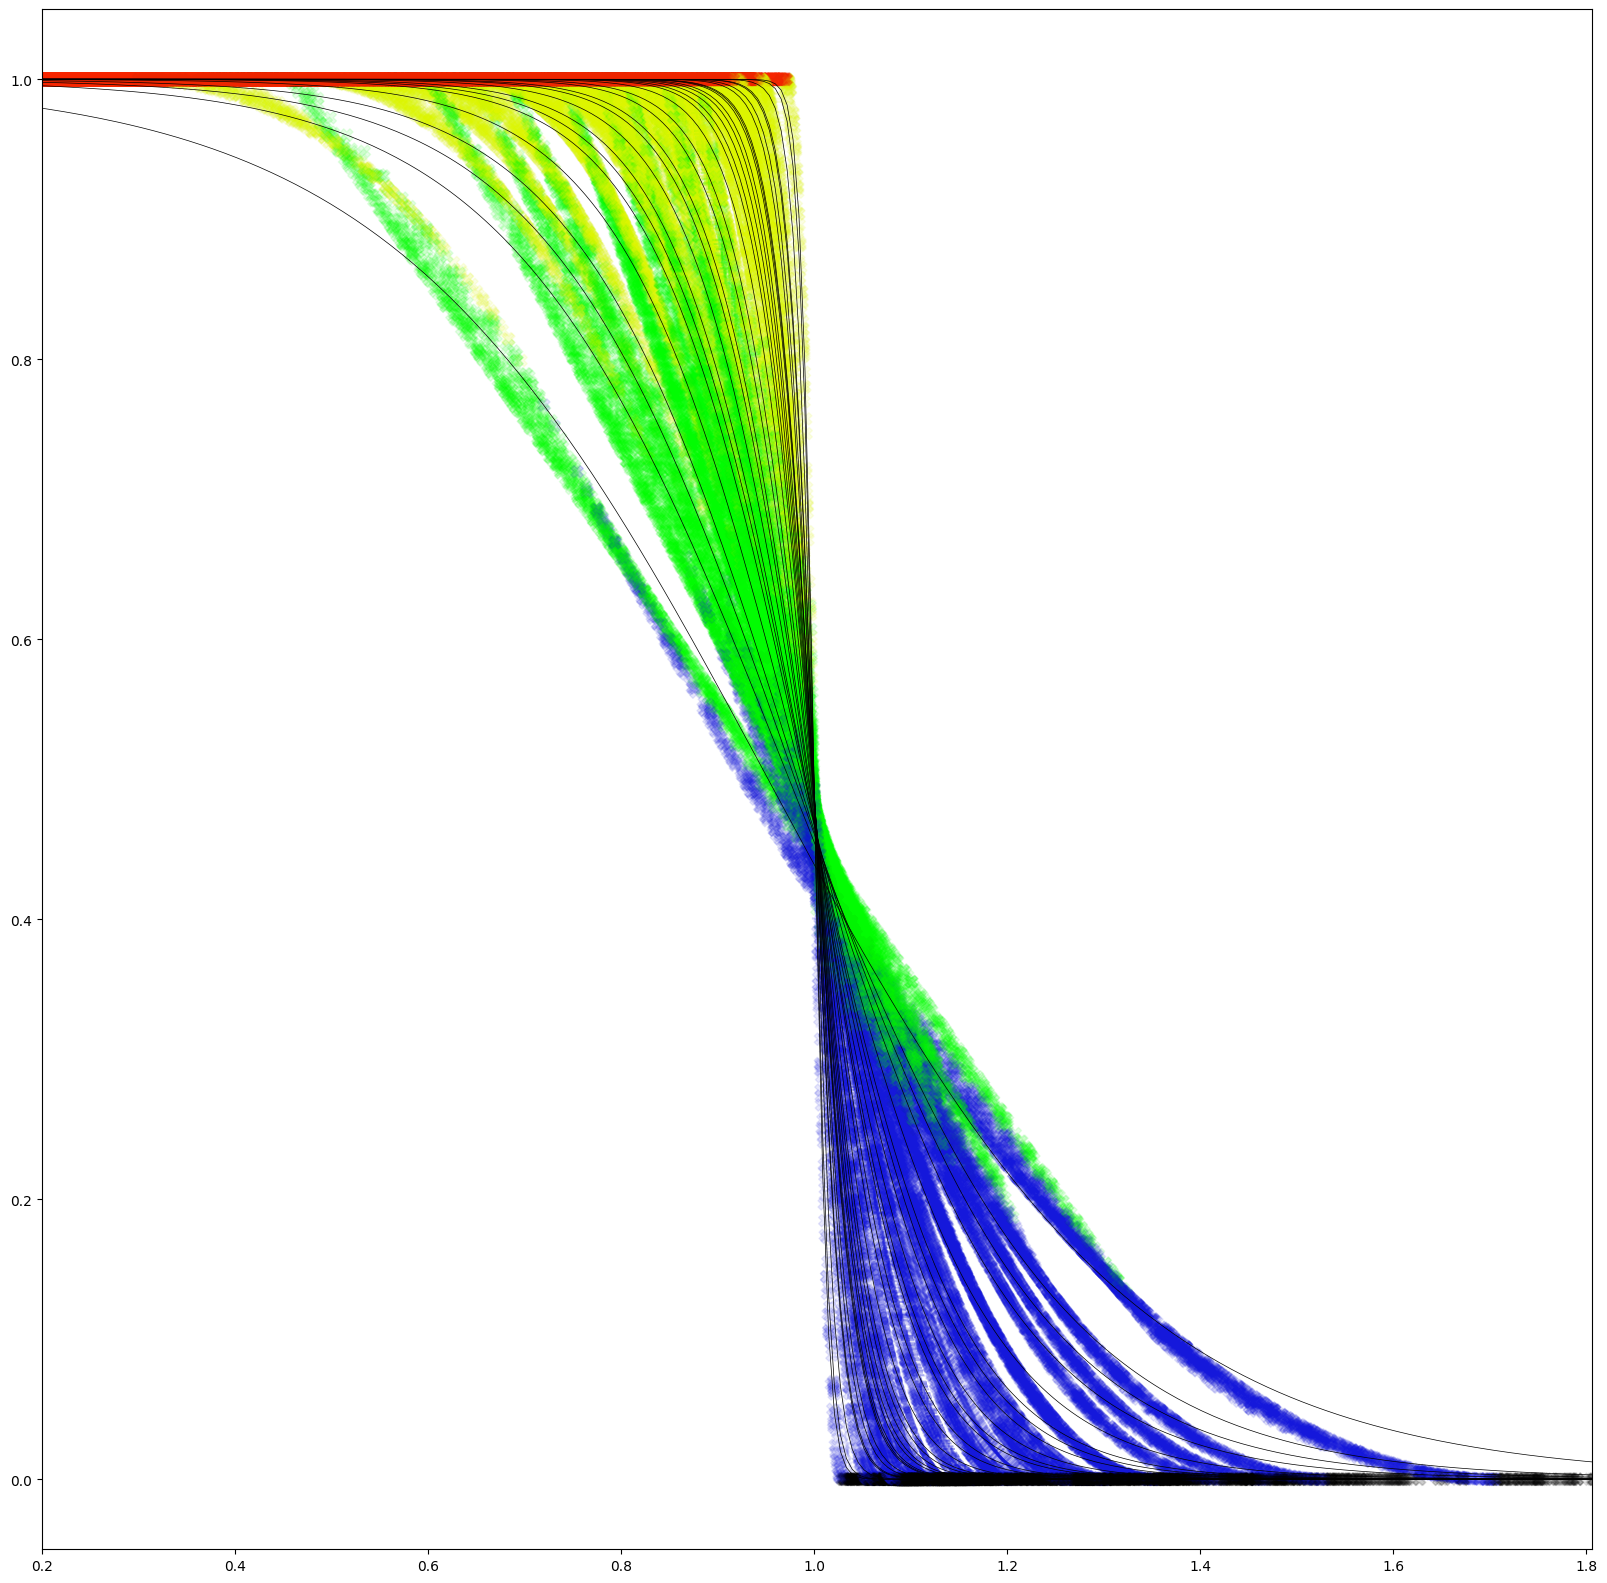

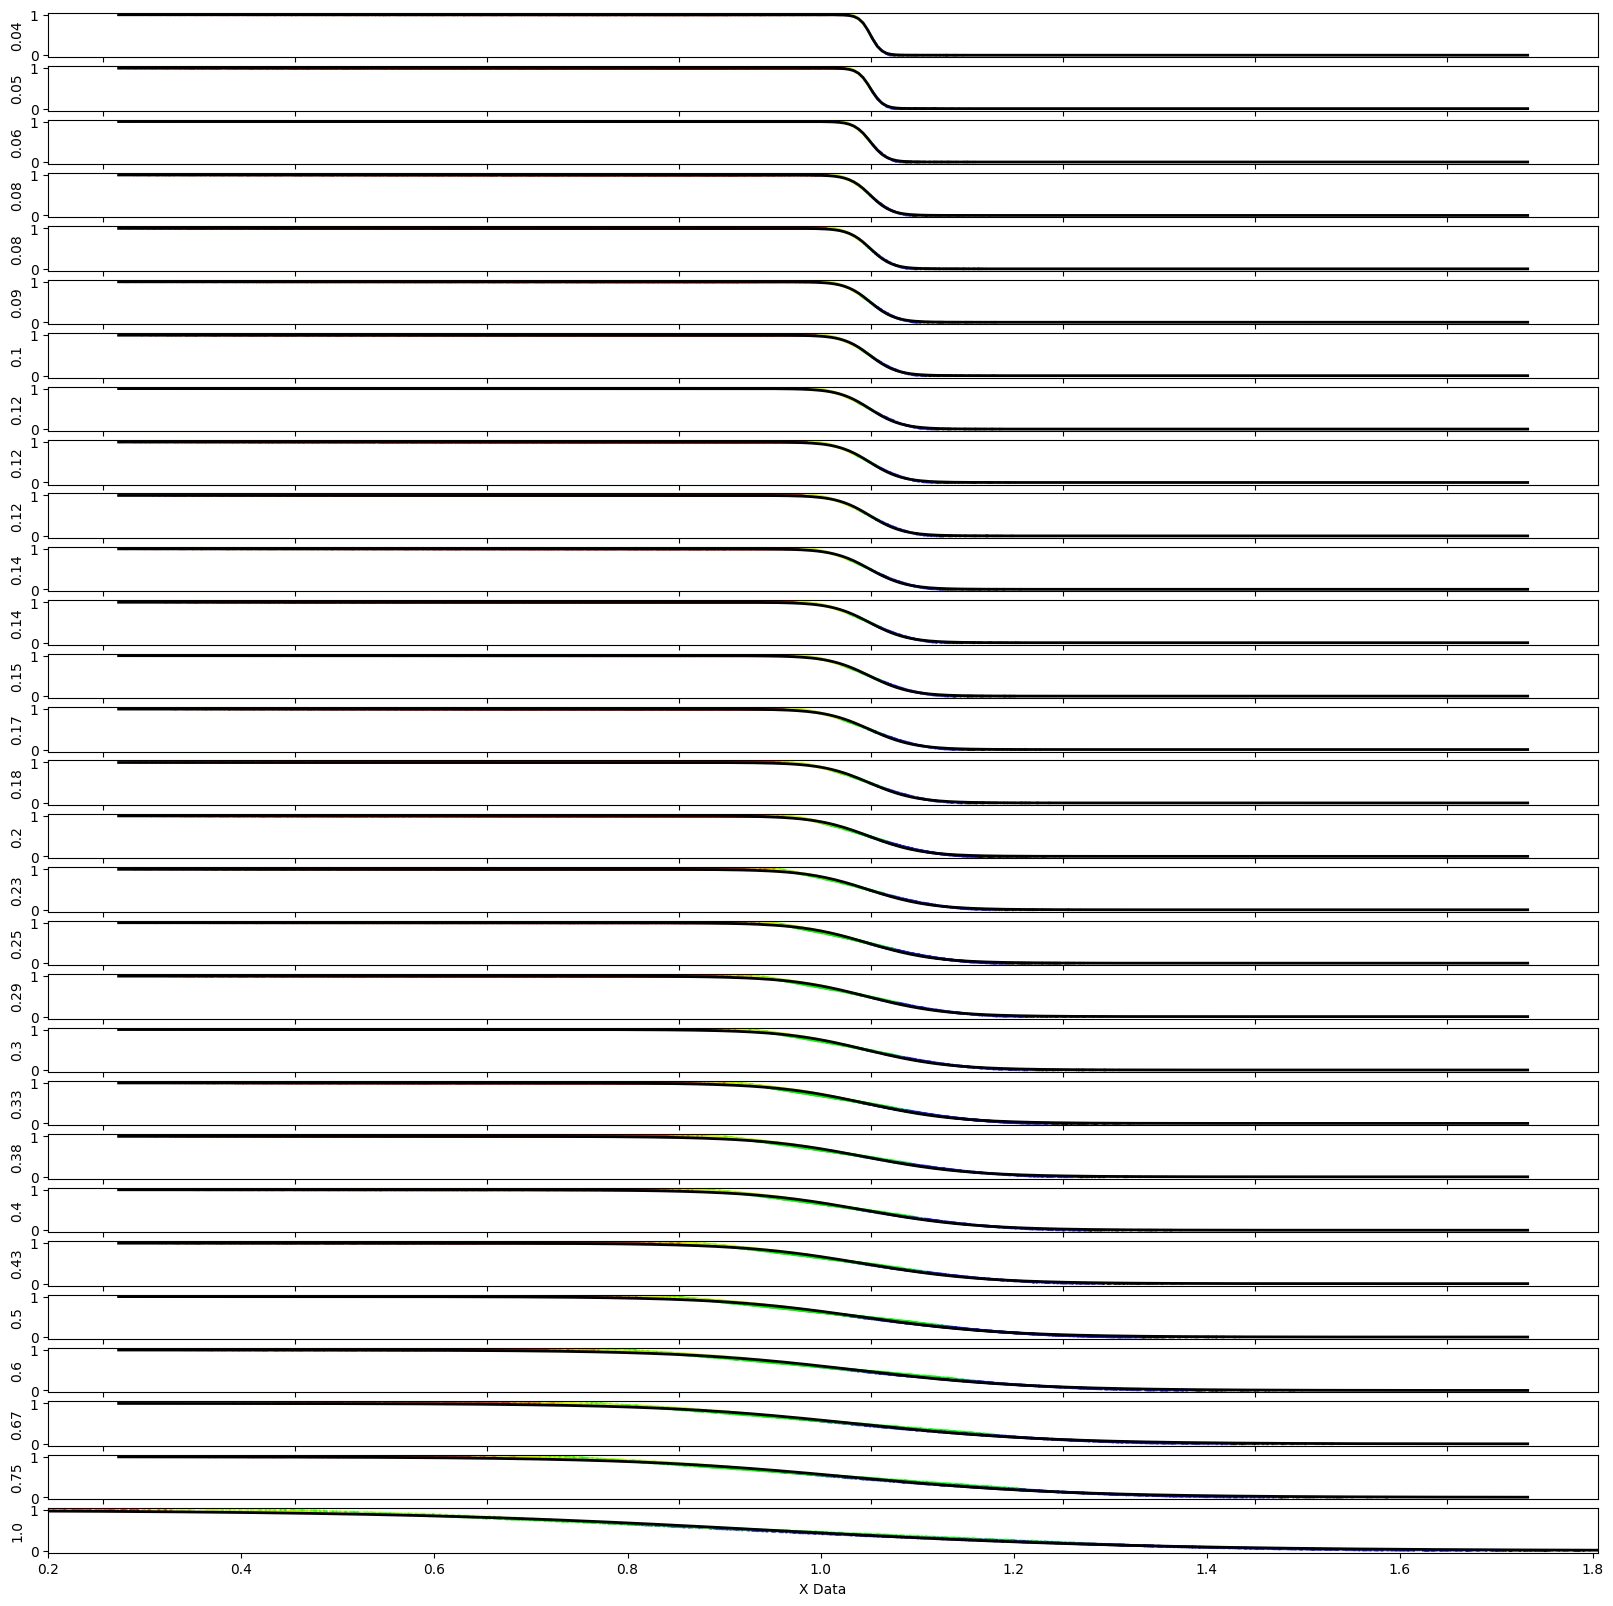

In [ ]:
import numpy, scipy, matplotlib
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.optimize import differential_evolution
import warnings
from aabpl.valid_area import disk_cell_intersection_area
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import Polygon, Point
from time import time
all_distances = []
all_areas = []
all_areas2 = []
all_colors = []
all_markers = []
all_spacing_norms=[]


spacings = [1,2,3]
radiuses = [3,4,5,6,7,8,10,13,17,22,25]

color_map = {0: "#00000000", 1: "#1518db00", 2:"#02fc02", 3:"#DCF50000", 4:"#f7250000"}
ratios = []
for spacing in spacings:
    for r in radiuses:
        if not spacing/r in ratios:
            ratios.append(spacing/r)
shapes = ['x','+','.','o', '*', '^', 'v', '1', '3']
shape_map = {ratio:s for ratio,s in zip(ratios, shapes)}

for spacing in spacings:
    for r in radiuses:
        ratio=spacing/r
        def estimate_overlapped_area_share(
            disk_center_pt_s:np.array,      
            centroid_s:tuple=np.array,
            logit_Q:float=1 / (0.70628102 + np.exp(0.57266908 * (spacing / r - 2))),
            logit_B:float=1 / (-0.21443453 + np.exp(0.76899004 * (spacing / r - 2))),
        ) -> np.array:
            """
            either disk_center_pt_s or centroid_s can be more than one element not both
            returns numpy.array with share of grid cells that is overlapped by radius each element is in [0,1] or in (0,1) if cell is truly only overlapped
            """
            return 1 - 1 / (
                1.0 + logit_Q * np.exp(
                    -logit_B * 
                        (1/r * np.linalg.norm(disk_center_pt_s-centroid_s, axis=1) - 1)
                    )
                ) 
        
        n=5000
        points = (np.random.random((int(n*1.4),2))-0.5)*(2*( 1/2*spacing + 1/(2**.5)*r)*1.1)
        # print("points",points)
        points = [(x,y) for x,y in points if abs(x)>0.5 or abs(y)>0.5 and (x**2+y**2)**.5 <= (spacing/(2**.5)+r)*1.3]
        points = points[:n]
        if len(points)<n:
            print("shape points", len(points))
        distances = np.linalg.norm(points, axis=1)
        distances_by_ratio = distances/r
        # print("distances", distances)
        areas = []
        areas2 = []
        colors = []
        cell = Polygon([(-spacing/2,-spacing/2), (spacing/2,-spacing/2), (spacing/2,spacing/2), (-spacing/2,spacing/2)])
        for pt,dbr in zip(points, distances_by_ratio):
            t0=time()
            res = disk_cell_intersection_area(
                disk_center_pt=pt,
                cell_bounds=((-spacing/2,-spacing/2),(spacing/2,spacing/2)),
                grid_spacing=spacing,
                r=r,
                silent=True,
                return_n_itx=True,
            )
            t_disk_cell += time()-t0
            area2 = estimate_overlapped_area_share(np.array([pt]), np.array([(0,0)])).sum()*spacing**2
            # t0=time()
            # area2 = Point(pt).buffer(r,quadsegs=16).intersection(cell).area
            # t_shapely_q16 += time()-t0
            
            
            area,vtx_in_r = res 
            areas.append(area/(spacing**2))
            areas2.append(area2/(spacing**2))
            colors.append(color_map[vtx_in_r])
        all_spacing_norms.append(spacing/r)
        all_distances.append(distances_by_ratio)
        all_areas.append(areas)
        all_areas2.append(areas2)
        all_colors.append(colors)
        all_markers.append(shape_map.get(ratio,'X'))
        # plt.scatter(x=[xy[0] for xy in points], y=[xy[1] for xy in points], s=1, alpha=0.2)
fig, ax = plt.subplots(figsize=(20,20))
xData,yData,y2Data,sData,cData = [],[],[],[],[]
for distances_by_ratio, areas, areas2, colors, marker, spacing_norm in zip(all_distances, all_areas, all_areas2, all_colors, all_markers, all_spacing_norms):
    xData = xData + list(distances_by_ratio)
    yData = yData + areas
    y2Data = y2Data + areas2
    sData = sData + list(numpy.zeros(len(areas)) + spacing_norm)
    cData = cData + list(colors)
    ax.scatter(x=distances_by_ratio, y=areas, s=80, alpha=0.1, c=colors, marker=marker,
                # edgecolors='black', linewidths=2
                )
xData, yData, y2Data, sData, cData = numpy.array(xData), numpy.array(yData), numpy.array(y2Data), numpy.array(sData), numpy.array(cData)
minx,maxx = min(xData[yData<1])-0.1,max(xData[yData>0])+0.1
ax.set_xlim([minx,maxx])
# xData = numpy.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0])
# yData = numpy.array([0.073, 2.521, 15.879, 48.365, 72.68, 90.298, 92.111, 93.44, 93.439, 93.389, 93.381, 93.367, 93.94, 93.269, 96.376])


def func(x, c):
    return 1 - 1 / (1.0 + numpy.exp(-c * (x - 1))) 
def func(x, b, c):
    return 1 - 1 / (1.0 + b * numpy.exp(-c * (x - 1))) 

df_list = []
all_fittedParameters = {}
all_RMSE = {}
all_R2 = {}
cmap = plt.get_cmap('gist_rainbow')
cmap2 = plt.get_cmap('binary')
cmap = plt.get_cmap('viridis')
cmap2 = plt.get_cmap('inferno')
unique_s = sorted(set(sData))
fig, axs = plt.subplots(nrows=len(unique_s),figsize=(20,20))
for n,s in enumerate(unique_s):
    axes = axs.flat[n] if hasattr(axs, 'flat') else axs
    _xData, _yData, _sData, _cData =  xData[sData==s], yData[sData==s], sData[sData==s], cData[sData==s]
    _cmap = cmap(n/len(unique_s))
    _cmap2 = cmap2(n/len(unique_s))
    # function for genetic algorithm to minimize (sum of squared error)
    def sumOfSquaredError(parameterTuple):
        warnings.filterwarnings("ignore") # do not print warnings by genetic algorithm
        val = func(_xData, *parameterTuple)
        return numpy.sum((_yData - val) ** 2.0)

    def generate_Initial_Parameters():
        parameterBounds = []
        # parameterBounds.append([0.9, 1.01]) # search bounds for a
        parameterBounds.append([0.5, 5]) # search bounds for b
        parameterBounds.append([0.0, 30.0]) # search bounds for c

        # "seed" the numpy random number generator for repeatable results
        result = differential_evolution(sumOfSquaredError, parameterBounds, seed=3)
        return result.x
    # by default, differential_evolution completes by calling curve_fit() using parameter bounds
    geneticParameters = generate_Initial_Parameters()

    # now call curve_fit without passing bounds from the genetic algorithm,
    # just in case the best fit parameters are aoutside those bounds
    fittedParameters, pcov = curve_fit(func, _xData, _yData, geneticParameters)
    # print('Fitted parameters:', fittedParameters, "div by s", [float(p/spacing) for p in fittedParameters], "div by p/s", [float(spacing/p) for p in fittedParameters])
    modelPredictions = func(_xData, *fittedParameters) 
    absError = modelPredictions - _yData
    SE = numpy.square(absError) # squared errors
    MSE = numpy.mean(SE) # mean squared errors
    RMSE = numpy.sqrt(MSE) # Root Mean Squared Error, RMSE
    Rsquared = 1.0 - (numpy.var(absError) / numpy.var(_yData))
    all_fittedParameters[s] = fittedParameters
    all_RMSE[s] = RMSE
    all_R2[s] = Rsquared
    df_list.append({
        'r':1,
        's':s,
        'MSE':MSE,
        'Rsquared':Rsquared,
        'b':fittedParameters[0],
        'c':fittedParameters[1],
    })
    ##########################################################
    # graphics output section
    # first the raw data as a scatter plot
    # axes.plot(_xData, _yData,  'D', alpha=0.3, color=_cmap)
    axes.scatter(_xData, _yData,  alpha=0.3, color=_cData, s=1)
    # create data for the fitted equation plot
    xModel = numpy.linspace(min(xData), max(xData),300)
    yModel = func(xModel, *fittedParameters)
    # now the model as a line plot
    # axes.plot(xModel, yModel, color=_cmap2, linewidth=5)
    axes.plot(xModel, yModel, color='black', linewidth=2)
    ax.plot(xModel, yModel, color='black', linewidth=0.5)
    axes.set_xlabel('X Data') # X axis data label
    axes.set_ylabel(str(round(s,2))) # Y axis data label
axes.set_xlim([minx,maxx])

In [ ]:
yDif = abs(yData[y2Data>0]-y2Data[y2Data>0])/y2Data[y2Data>0]
reverseColorMap = {v:k for k,v in color_map.items()}
digits=5
sorted([(reverseColorMap[c],round(float(min(yD)),digits),round(float(sum(yD)/len(yD)),digits),round(float(max(yD)),digits)) for (c,yD) in
     [(c, yDif[cData[y2Data>0]==c]) for c in sorted(set(cData[y2Data>0]))]   
     ])

[(0, 1.0, 1.0, 1.0),
 (1, 0.0, 0.21283, 1.0),
 (2, 0.0, 0.02739, 0.24709),
 (3, 0.0, 0.03225, 0.12193),
 (4, 0.0, 0.00282, 0.09218)]

In [ ]:
yDif = abs(yData[y2Data>0]-y2Data[y2Data>0])#/y2Data[y2Data>0]
reverseColorMap = {v:k for k,v in color_map.items()}
digits=8
sorted([(reverseColorMap[c],round(float(min(yD)),digits),round(float(sum(yD)/len(yD)),digits),round(float(max(yD)),digits)) for (c,yD) in
     [(c, yDif[cData[y2Data>0]==c]) for c in sorted(set(cData[y2Data>0]))]   
     ])

[(0, 1.3e-07, 0.00353891, 0.02153518),
 (1, 2.64e-06, 0.13572499, 0.70377087),
 (2, 3.93e-06, 0.4693893, 0.90307925),
 (3, 1.798e-05, 0.58882843, 0.89900774),
 (4, 0.0, 0.46639593, 0.89867717)]

geneticParameters [ 0.         -2.14962503]
fittedParameters c [-0.21166836 -0.77535833]
geneticParameters [ 0.         -2.14962503]
fittedParameters b [ 0.70427867 -0.56810316]


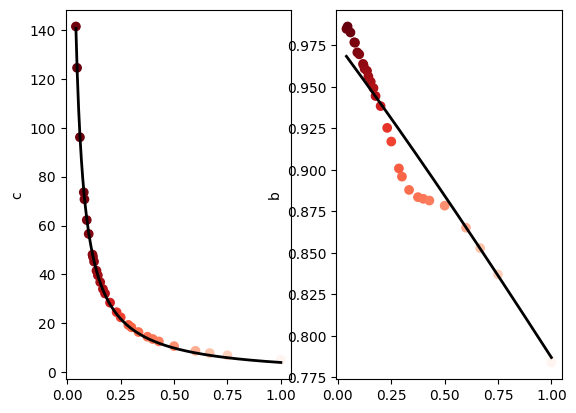

In [ ]:
df = pd.DataFrame(df_list)
fig, axes = plt.subplots(ncols=2)


def func2(x, a, c):
    return 0. + 1 / (a + numpy.exp(-c * (x - 2))) 

def sumOfSquaredError(parameterTuple):
    warnings.filterwarnings("ignore") # do not print warnings by genetic algorithm
    val = func2(df['s'].values, *parameterTuple)
    return numpy.sum((df['c'].values - val) ** 2.0)

def generate_Initial_Parameters():
    parameterBounds = []
    parameterBounds.append([0, 11]) # search bounds for a
    # parameterBounds.append([0, 15]) # search bounds for b
    parameterBounds.append([-13.1, 14.0]) # search bounds for c
    # parameterBounds.append([0.0, 3.0]) # search bounds for d
    # "seed" the numpy random number generator for repeatable results
    result = differential_evolution(sumOfSquaredError, parameterBounds, seed=3)
    return result.x
# by default, differential_evolution completes by calling curve_fit() using parameter bounds
geneticParameters = generate_Initial_Parameters()
print("geneticParameters", geneticParameters)
# now call curve_fit without passing bounds from the genetic algorithm,
# just in case the best fit parameters are aoutside those bounds
fittedParameters, pcov = curve_fit(func2, df['s'], df['c'], geneticParameters)
# print('Fitted parameters:', fittedParameters, "div by s", [float(p/spacing) for p in fittedParameters], "div by p/s", [float(spacing/p) for p in fittedParameters])
modelPredictions = func2(df['s'], *fittedParameters) 
absError = modelPredictions - df['c']
SE = numpy.square(absError) # squared errors
MSE = numpy.mean(SE) # mean squared errors
RMSE = numpy.sqrt(MSE) # Root Mean Squared Error, RMSE
Rsquared = 1.0 - (numpy.var(absError) / numpy.var(df['c']))
cmap3 = plt.get_cmap('Reds')
axes.flat[0].scatter(x=df['s'],y=df['c'], c=df['Rsquared'], cmap=cmap3)
axes.flat[0].set_ylabel("c")
xModel = numpy.linspace(min(df['s']), max(df['s']),300)
yModel = func2(xModel, *fittedParameters)
axes.flat[0].plot(xModel, yModel, color='black', linewidth=2)
print("fittedParameters c", fittedParameters)


geneticParameters = generate_Initial_Parameters()
print("geneticParameters",geneticParameters)
# now call curve_fit without passing bounds from the genetic algorithm,
# just in case the best fit parameters are aoutside those bounds
fittedParameters, pcov = curve_fit(func2, df['s'], df['b'], geneticParameters)
# print('Fitted parameters:', fittedParameters, "div by s", [float(p/spacing) for p in fittedParameters], "div by p/s", [float(spacing/p) for p in fittedParameters])
modelPredictions = func2(df['s'], *fittedParameters) 
absError = modelPredictions - df['b']
SE = numpy.square(absError) # squared errors
MSE = numpy.mean(SE) # mean squared errors
RMSE = numpy.sqrt(MSE) # Root Mean Squared Error, RMSE
Rsquared = 1.0 - (numpy.var(absError) / numpy.var(df['b']))
axes.flat[1].scatter(x=df['s'],y=df['b'], c=df['Rsquared'], cmap=cmap3)
axes.flat[1].set_ylabel("b") # Y axis data label
xModel = numpy.linspace(min(df['s']), max(df['s']),300)
yModel = func2(xModel, *fittedParameters)
axes.flat[1].plot(xModel, yModel, color='black', linewidth=2)
print("fittedParameters b", fittedParameters)

(0.19513892523588153, 1.8068414582700754)

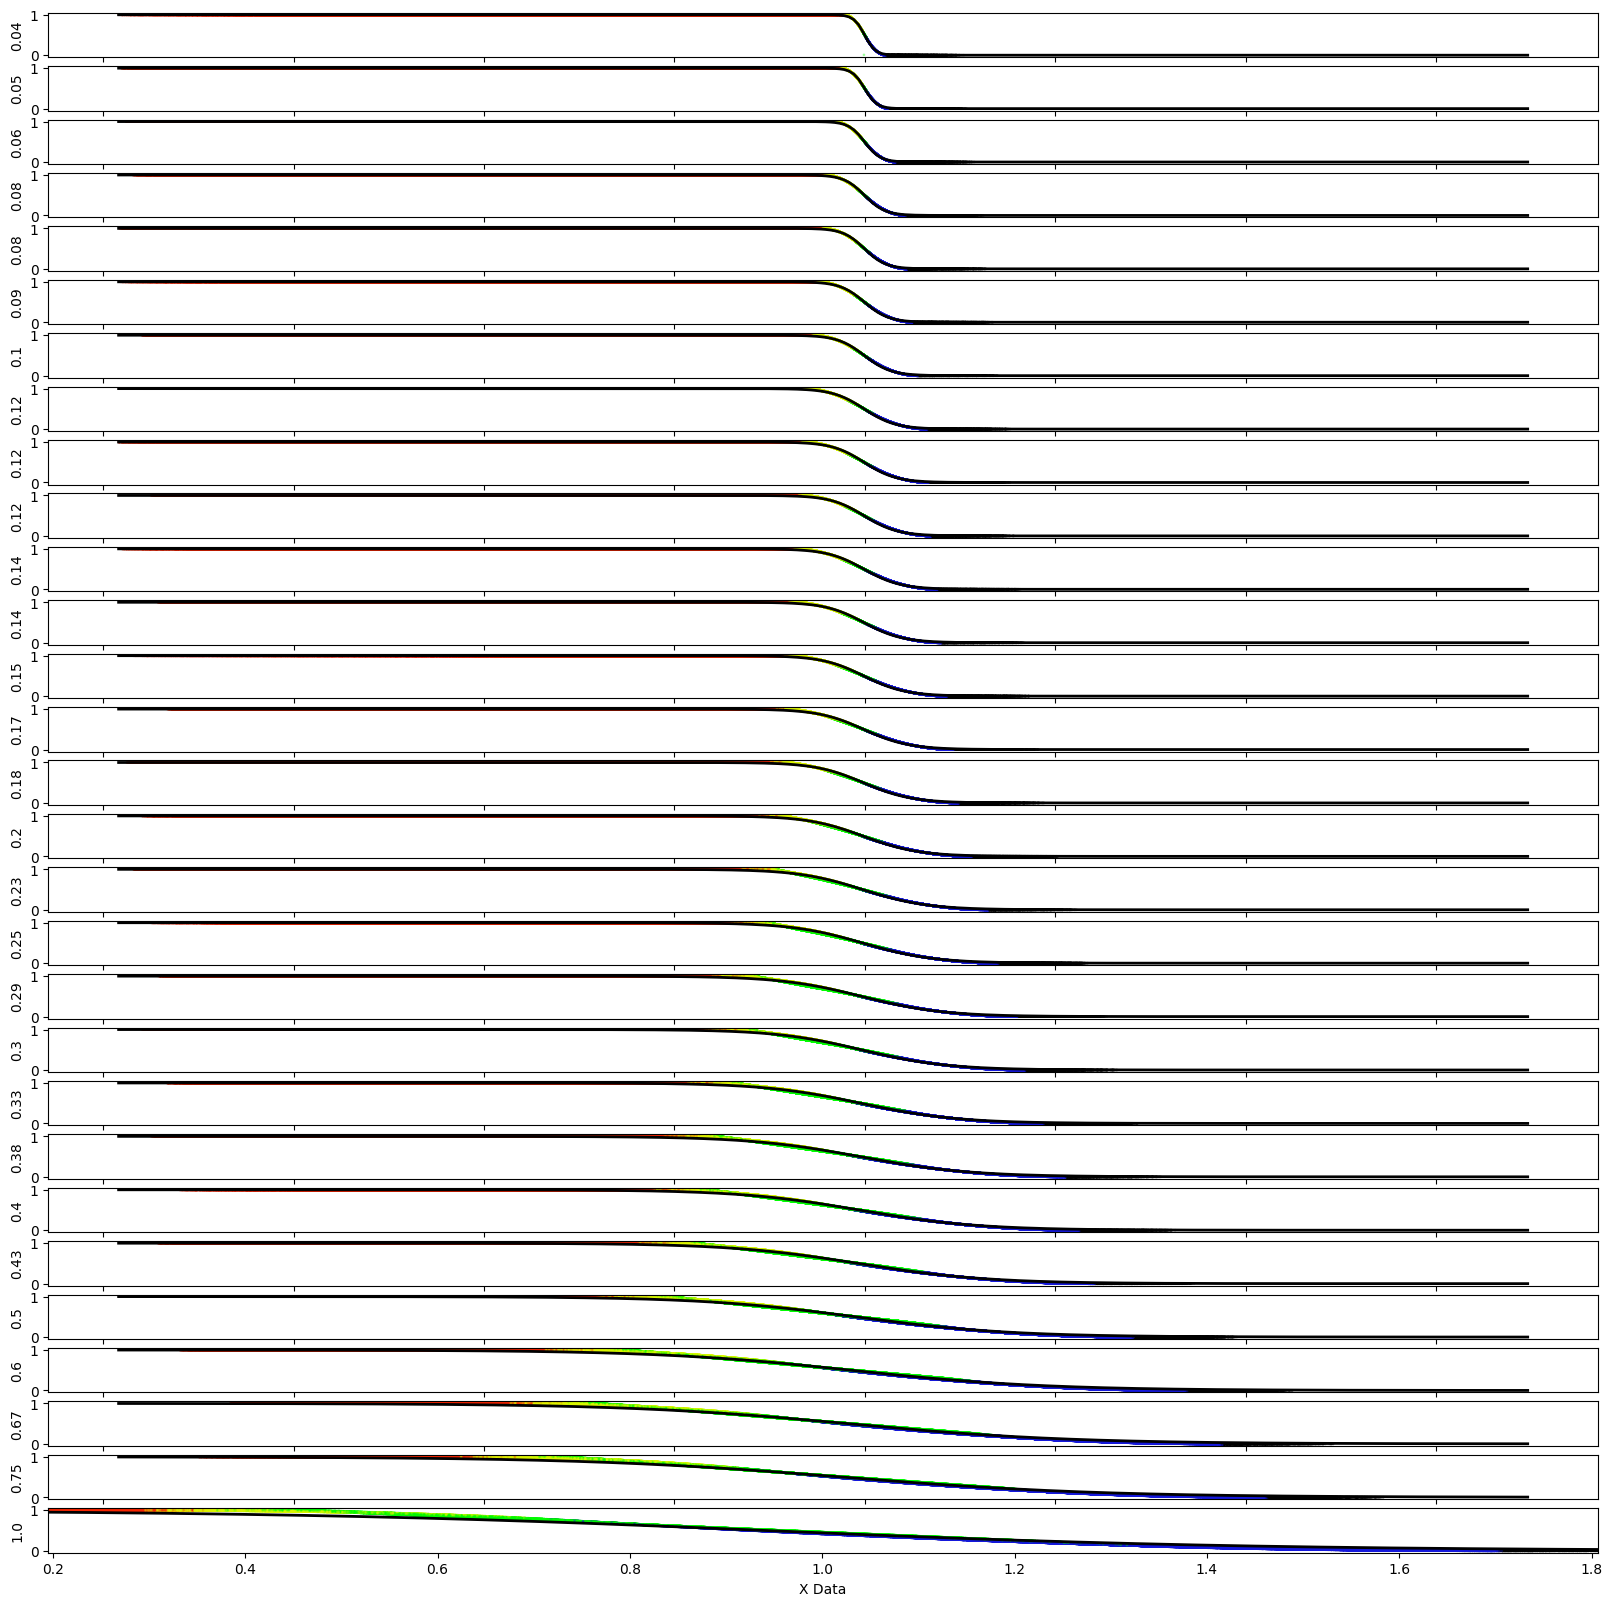

In [ ]:

# for distances_by_ratio, areas, colors, marker, spacing_norm in zip(all_distances, all_areas, all_colors, all_markers, all_spacing_norms):
#     xData = xData + list(distances_by_ratio)
#     yData = yData + areas
#     sData = sData + list(numpy.zeros(len(areas)) + spacing_norm)
#     cData = cData + list(colors)
#     ax.scatter(x=distances_by_ratio, y=areas, s=80, alpha=0.1, c=colors, marker=marker,
#                 # edgecolors='black', linewidths=2
#                 )
# xData, yData, sData, cData = numpy.array(xData), numpy.array(yData), numpy.array(sData), numpy.array(cData)
# minx,maxx = min(xData[yData<1])-0.1,max(xData[yData>0])+0.1
# ax.set_xlim([minx,maxx])
# # xData = numpy.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0])
# # yData = numpy.array([0.073, 2.521, 15.879, 48.365, 72.68, 90.298, 92.111, 93.44, 93.439, 93.389, 93.381, 93.367, 93.94, 93.269, 96.376])


def func(x, b, c):
    return 1 - 1 / (1.0 + b * numpy.exp(-c * (x - 1))) 

cmap = plt.get_cmap('gist_rainbow')
cmap2 = plt.get_cmap('binary')
cmap = plt.get_cmap('viridis')
cmap2 = plt.get_cmap('inferno')
unique_s = sorted(set(sData))
fig, axs = plt.subplots(nrows=len(unique_s),figsize=(20,20))
for n,s in enumerate(unique_s):
    axes = axs.flat[n] if hasattr(axs, 'flat') else axs
    _xData, _yData, _sData, _cData =  xData[sData==s], yData[sData==s], sData[sData==s], cData[sData==s]
    _cmap = cmap(n/len(unique_s))
    _cmap2 = cmap2(n/len(unique_s))
    # function for genetic algorithm to minimize (sum of squared error)
    #s=s/r
    fittedParameters = [
        1 / (0.70628102 + numpy.exp(0.57266908 * (s - 2))), # b
        1 / (-0.21443453 + numpy.exp(0.76899004 * (s - 2))) # c
    ]
    modelPredictions = func(_xData, *fittedParameters) 
  
    ##########################################################
    # graphics output section
    # first the raw data as a scatter plot
    # axes.plot(_xData, _yData,  'D', alpha=0.3, color=_cmap)
    axes.scatter(_xData, _yData,  alpha=0.3, color=_cData, s=1)
    # create data for the fitted equation plot
    xModel = numpy.linspace(min(xData), max(xData),300)
    yModel = func(xModel, *fittedParameters)
    # now the model as a line plot
    # axes.plot(xModel, yModel, color=_cmap2, linewidth=5)
    axes.plot(xModel, yModel, color='black', linewidth=2)
    ax.plot(xModel, yModel, color='black', linewidth=0.5)
    axes.set_xlabel('X Data') # X axis data label
    axes.set_ylabel(str(round(s,2))) # Y axis data label
axes.set_xlim([minx,maxx])